In [4]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, adjusted_rand_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("pima_indians_diabetes_with_header.csv")

In [6]:
df.shape

(768, 9)

=== K-Means Clustering Evaluation ===
Akurasi       : 67.45%
F1 Score      : 0.5353
Precision     : 0.5333
Recall        : 0.5373
Adjusted Rand : 0.1137
Silhouette    : 0.1960
Tebakan benar : 518
Tebakan salah : 250


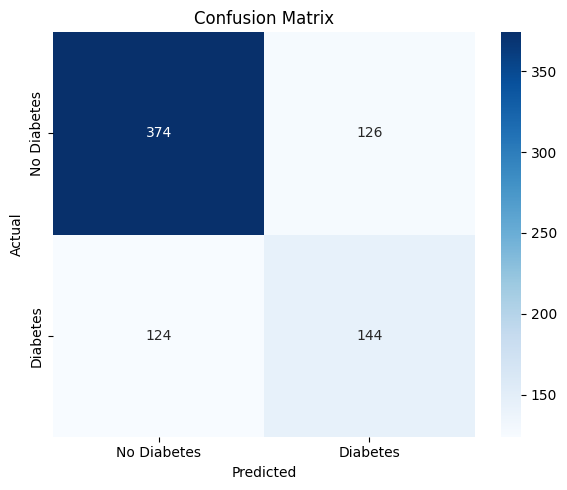

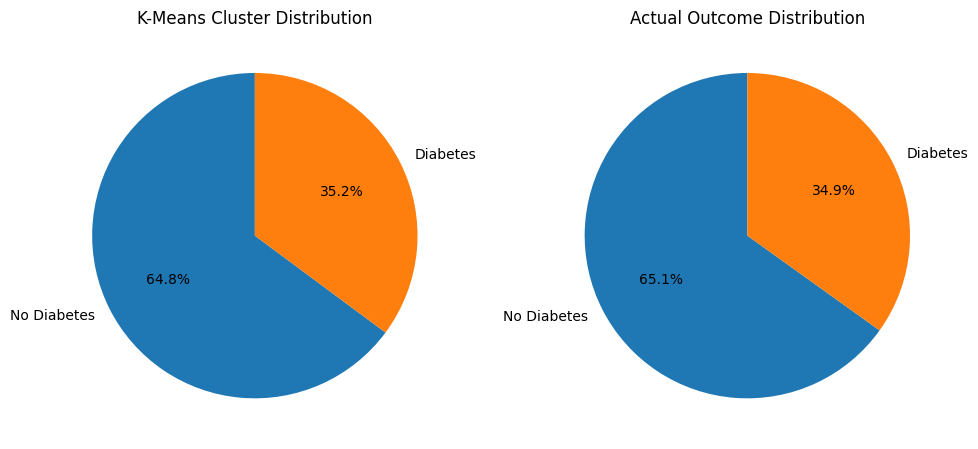

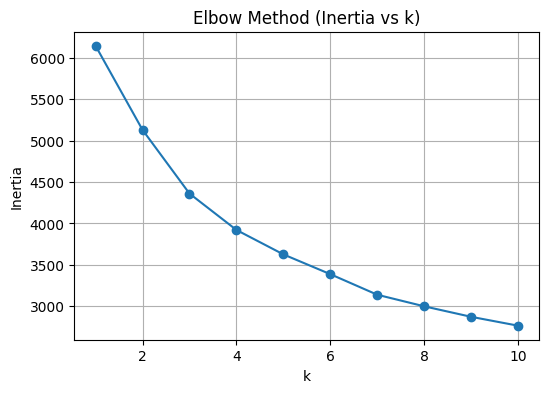

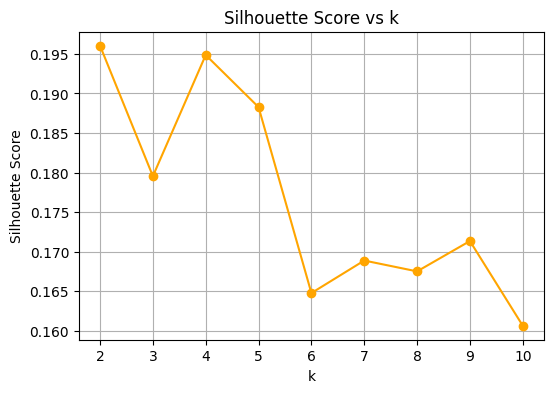


=== Mapping Cluster ke Label Asli ===
TrueLabel    0    1  Most Similar to Label
Cluster                                   
0          374  124                      0
1          126  144                      1


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, confusion_matrix, adjusted_rand_score,
    f1_score, precision_score, recall_score, silhouette_score
)

# 1. Load data
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
X = df.drop(columns="Outcome")
y_true = df["Outcome"]

# 2. StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA untuk reduksi dimensi (2D visualisasi)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. KMeans Clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. Cek dan sesuaikan label
if accuracy_score(y_true, clusters) < 0.5:
    clusters = 1 - clusters

# 6. Evaluasi metrik
acc = accuracy_score(y_true, clusters)
f1 = f1_score(y_true, clusters)
precision = precision_score(y_true, clusters)
recall = recall_score(y_true, clusters)
ari = adjusted_rand_score(y_true, clusters)
silhouette = silhouette_score(X_scaled, clusters)
conf_mat = confusion_matrix(y_true, clusters)
true_positives = (y_true == clusters).sum()
false_predictions = (y_true != clusters).sum()

# 7. Print evaluasi
print("=== K-Means Clustering Evaluation ===")
print(f"Akurasi       : {acc * 100:.2f}%")
print(f"F1 Score      : {f1:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"Adjusted Rand : {ari:.4f}")
print(f"Silhouette    : {silhouette:.4f}")
print(f"Tebakan benar : {true_positives}")
print(f"Tebakan salah : {false_predictions}")

# 8. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# 9. Pie Chart perbandingan distribusi
cluster_counts = pd.Series(clusters).value_counts().sort_index()
actual_counts = y_true.value_counts().sort_index()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].pie(cluster_counts, labels=["No Diabetes", "Diabetes"], autopct='%1.1f%%', startangle=90)
axs[0].set_title("K-Means Cluster Distribution")
axs[1].pie(actual_counts, labels=["No Diabetes", "Diabetes"], autopct='%1.1f%%', startangle=90)
axs[1].set_title("Actual Outcome Distribution")
plt.tight_layout()
plt.show()


# 11. Elbow Method untuk cari k terbaik
inertias = []
k_range = range(1, 11)
for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(k_range, inertias, marker='o')
plt.title("Elbow Method (Inertia vs k)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

# 12. Silhouette Score untuk berbagai k
sil_scores = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)

plt.figure(figsize=(6, 4))
plt.plot(range(2, 11), sil_scores, marker='o', color='orange')
plt.title("Silhouette Score vs k")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# 13. Mapping: Cluster 0/1 lebih mirip label 0/1?
df_compare = pd.DataFrame({'Cluster': clusters, 'TrueLabel': y_true})
mapping_result = df_compare.groupby('Cluster')['TrueLabel'].value_counts().unstack().fillna(0).astype(int)
mapping_result['Most Similar to Label'] = mapping_result.idxmax(axis=1)
print("\n=== Mapping Cluster ke Label Asli ===")
print(mapping_result)


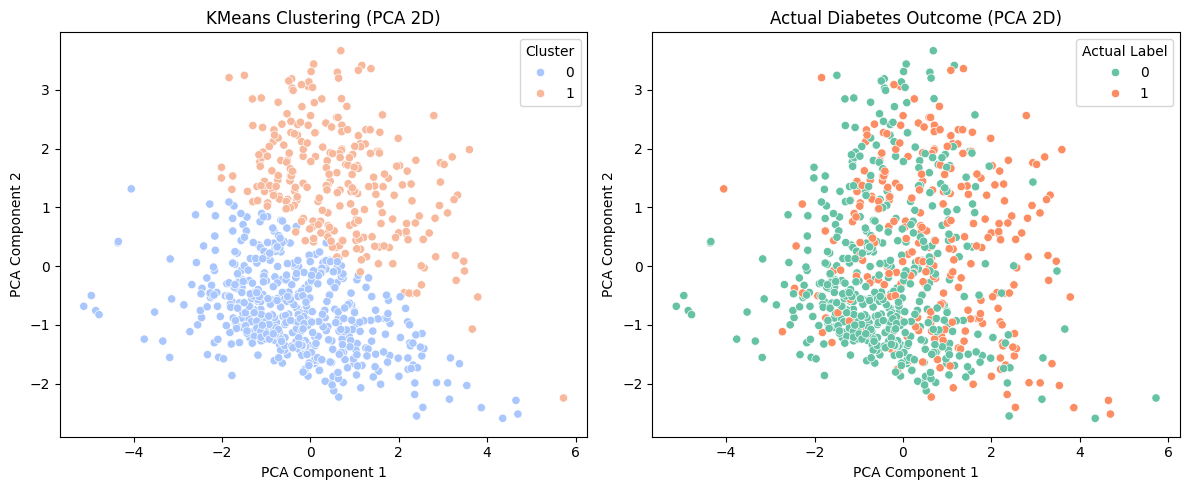

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Buat figure dengan 2 plot samping-sampingan
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Hasil KMeans Clustering (berdasarkan cluster label)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='coolwarm', ax=axs[0])
axs[0].set_title("KMeans Clustering (PCA 2D)")
axs[0].set_xlabel("PCA Component 1")
axs[0].set_ylabel("PCA Component 2")
axs[0].legend(title="Cluster")

# Plot 2: Ground Truth dari label asli
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, palette='Set2', ax=axs[1])
axs[1].set_title("Actual Diabetes Outcome (PCA 2D)")
axs[1].set_xlabel("PCA Component 1")
axs[1].set_ylabel("PCA Component 2")
axs[1].legend(title="Actual Label")

# Tampilkan kedua plot
plt.tight_layout()
plt.show()


=== Perbedaan Rata-rata Tiap Fitur antar Cluster ===
Age                         19.515309
Insulin                     17.587655
Glucose                     16.509514
BloodPressure                9.742147
Pregnancies                  5.320635
SkinThickness                4.344301
BMI                          0.534550
Outcome                      0.259170
DiabetesPedigreeFunction     0.002703
Name: 1, dtype: float64


C:\Users\71485\AppData\Local\Temp\ipykernel_4724\2529156838.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_diff.values, y=cluster_diff.index, palette='viridis')


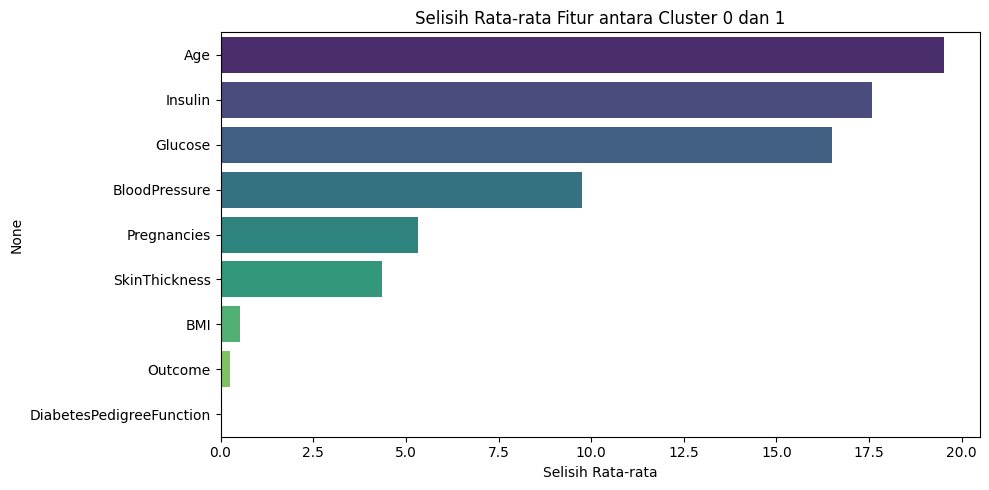

In [22]:
# Tambahkan hasil cluster ke dataframe asli
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans_labels

# Hitung rata-rata tiap fitur per cluster
cluster_means = df_clustered.groupby('Cluster').mean()

# Hitung selisih antara cluster 0 dan 1
cluster_diff = cluster_means.diff().iloc[-1].abs().sort_values(ascending=False)

print("=== Perbedaan Rata-rata Tiap Fitur antar Cluster ===")
print(cluster_diff)

# Optional: Barplot visualisasi selisih rata-rata
plt.figure(figsize=(10, 5))
sns.barplot(x=cluster_diff.values, y=cluster_diff.index, palette='viridis')
plt.title("Selisih Rata-rata Fitur antara Cluster 0 dan 1")
plt.xlabel("Selisih Rata-rata")
plt.tight_layout()
plt.show()


In [23]:
# Lihat statistik ringkasan tiap cluster
print(df_clustered.groupby('Cluster').describe())

        Pregnancies                                               Glucose  \
              count      mean       std  min  25%  50%  75%   max   count   
Cluster                                                                     
0             511.0  2.064579  1.737064  0.0  1.0  2.0  3.0   7.0   511.0   
1             257.0  7.385214  3.016144  0.0  6.0  7.0  9.0  17.0   257.0   

                     ...   Age       Outcome                                \
               mean  ...   75%   max   count      mean       std  min  25%   
Cluster              ...                                                     
0        115.369863  ...  29.0  47.0   511.0  0.262231  0.440279  0.0  0.0   
1        131.879377  ...  53.0  81.0   257.0  0.521401  0.500517  0.0  0.0   

                        
         50%  75%  max  
Cluster                 
0        0.0  1.0  1.0  
1        1.0  1.0  1.0  

[2 rows x 72 columns]


In [25]:
# Tambahkan label cluster ke data asli
df_clustered = df.copy()
df_clustered['Cluster'] = kmeans_labels

# Buat summary statistik mean untuk tiap fitur per cluster
cluster_means = df_clustered.groupby('Cluster').mean()

# Tampilkan ringkasan dengan pembulatan variabel diskrit (biar lebih masuk akal)
summary = pd.DataFrame({
    'Pregnancies': cluster_means['Pregnancies'].round(0).astype(int),
    'Glucose': cluster_means['Glucose'].round(1),
    'Insulin': cluster_means['Insulin'].round(1),
    'Age': cluster_means['Age'].round(1),
    'Outcome (Persentase Diabetes)': (cluster_means['Outcome'] * 100).round(1)
}).reset_index()

# Tampilkan hasilnya
print("=== Ringkasan Karakteristik Tiap Cluster ===")
print(summary)


=== Ringkasan Karakteristik Tiap Cluster ===
   Cluster  Pregnancies  Glucose  Insulin   Age  Outcome (Persentase Diabetes)
0        0            2    115.4     85.7  26.7                           26.2
1        1            7    131.9     68.1  46.2                           52.1


Contingency Table Cluster vs Metabolic Syndrome:
MetabolicSyndrome   0   1
cluster                  
0                  58  30
1                   1   4


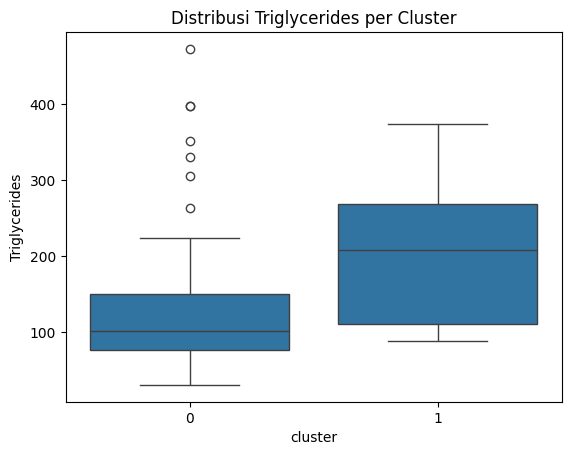

Korelasi fitur dengan cluster:
cluster              1.000000
BloodGlucose         0.747224
WaistCirc            0.224923
Triglycerides        0.218130
MetabolicSyndrome    0.215010
BMI                  0.170721
UricAcid             0.088267
HDL                 -0.118398
Name: cluster, dtype: float64


In [53]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns

# Gabungkan fitur yang ada di kedua dataset
df_common = df[['BMI', 'Glucose']].copy()
df_common = df_common.rename(columns={'Glucose': 'BloodGlucose'})

# Tambahkan label cluster dari KMeans (buat ulang dengan 2 cluster)
kmeans = KMeans(n_clusters=2, random_state=42)
df_common['cluster'] = kmeans.fit_predict(df_common)

# Gabungkan dengan data metabolic berdasarkan BloodGlucose dan BMI
df_merged = pd.merge(df_common, df_metabolic[['BMI', 'BloodGlucose', 'MetabolicSyndrome',
                                               'WaistCirc', 'UricAcid', 'Triglycerides', 'HDL']],
                     on=['BMI', 'BloodGlucose'], how='inner')

# Lihat distribusi cluster vs Metabolic Syndrome
ct = pd.crosstab(df_merged['cluster'], df_merged['MetabolicSyndrome'])
print("Contingency Table Cluster vs Metabolic Syndrome:")
print(ct)

# Visualisasi
sns.boxplot(data=df_merged, x='cluster', y='Triglycerides')
plt.title("Distribusi Triglycerides per Cluster")
plt.show()

# Korelasi fitur dengan cluster
correlations = df_merged.corr(numeric_only=True)['cluster'].sort_values(ascending=False)
print("Korelasi fitur dengan cluster:")
print(correlations)


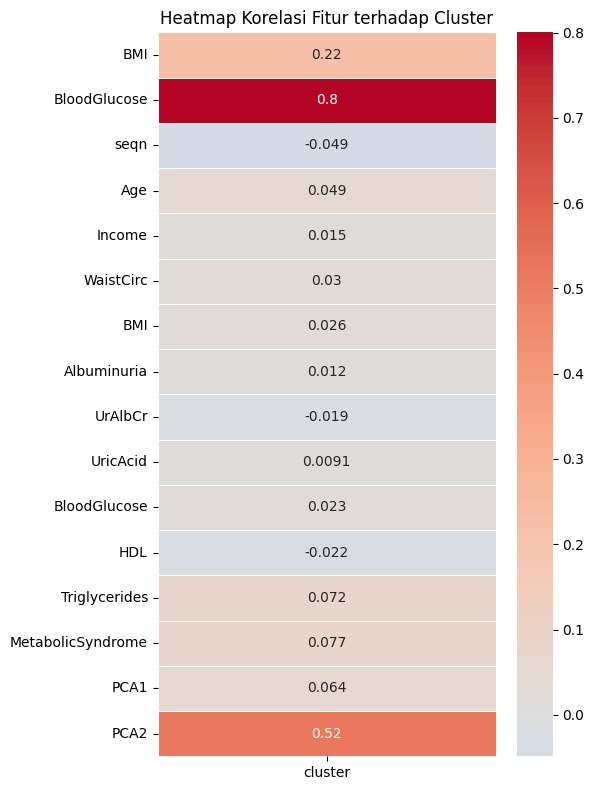

In [73]:
import seaborn as sns
import matplotlib.pyplot as plt

# Hitung korelasi antar semua fitur numerik
corr_matrix = df_merged.corr(numeric_only=True)

# Ambil hanya korelasi terhadap kolom 'cluster'
corr_cluster = corr_matrix[['cluster']].drop('cluster')  # hilangkan korelasi diri sendiri

# Plot heatmap
plt.figure(figsize=(6, 8))
sns.heatmap(corr_cluster, annot=True, cmap='coolwarm', center=0, linewidths=0.5)
plt.title("Heatmap Korelasi Fitur terhadap Cluster")
plt.tight_layout()
plt.show()


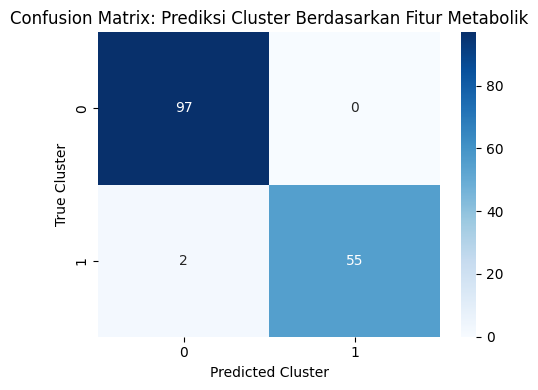

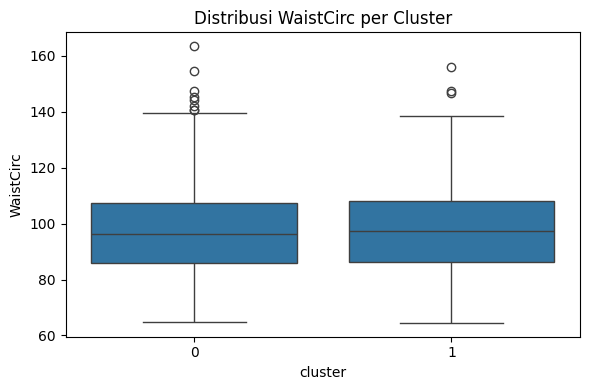

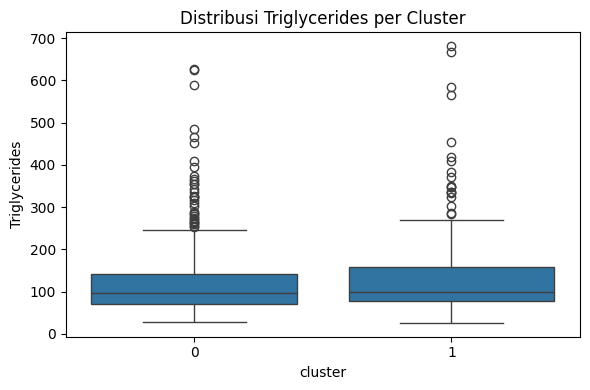

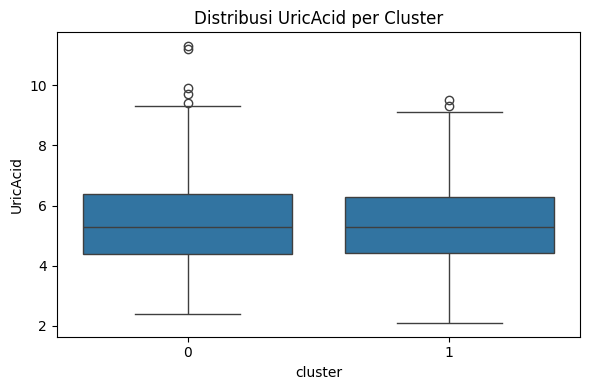

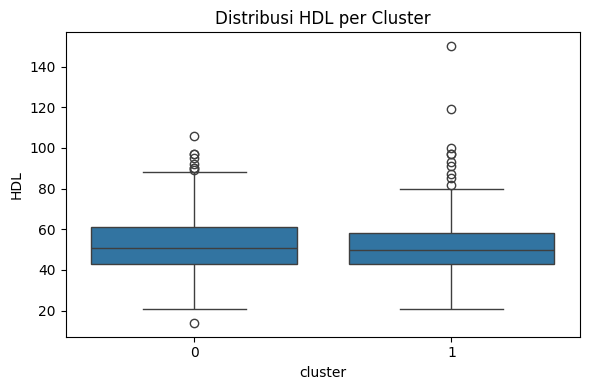

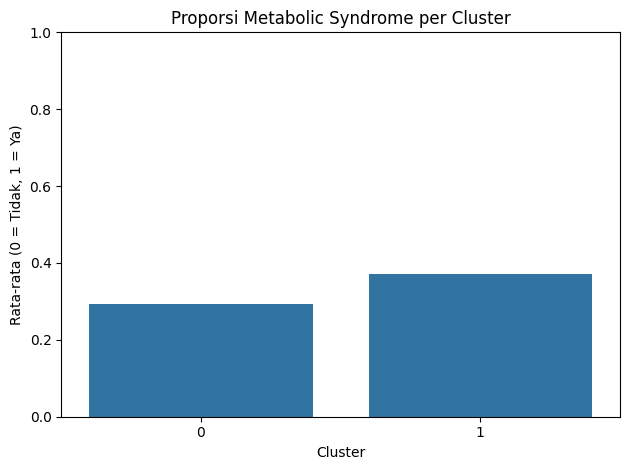

C:\Users\71485\AppData\Local\Temp\ipykernel_4724\1849824383.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlations.values[1:], y=correlations.index[1:], palette='viridis')


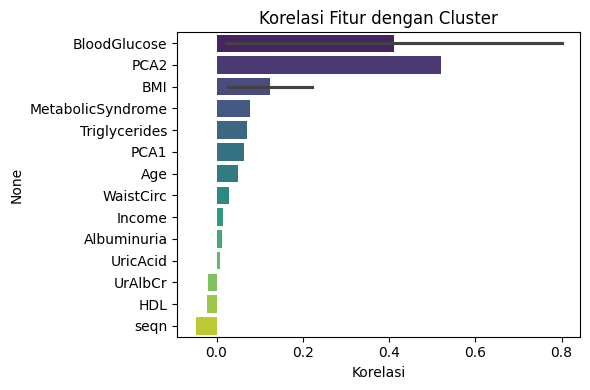


=== Ringkasan dan Labeling Tiap Cluster ===
   cluster  Pregnancies  Glucose  Insulin   Age   Age  Outcome  \
0        0          3.5    102.9     58.3  31.0  47.3      0.2   
1        1          4.5    157.3    123.4  37.8  49.1      0.6   

   MetabolicSyndrome  Persentase Diabetes  Persentase MetabolicSyndrome  \
0                0.3                 20.0                          30.0   
1                0.4                 60.0                          40.0   

     Label_Cluster  
0   Low Risk Group  
1  High Risk Group  


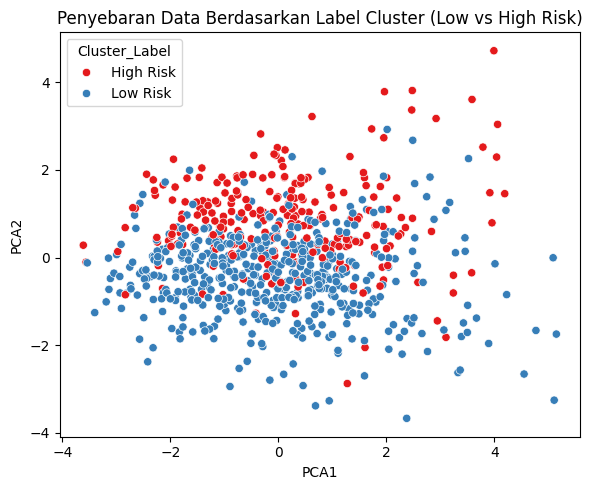


=== Proporsi Outcome & MetabolicSyndrome per Cluster ===
   cluster  Persentase Diabetes  Persentase MetabolicSyndrome    Label_Cluster
0        0                 20.0                          30.0   Low Risk Group
1        1                 60.0                          40.0  High Risk Group


In [ ]:
# Finalized Clean Python Script for Clustering & Analysis

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# =====================
# 1. Load data
# =====================
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
df_metabolic = pd.read_csv("Metabolic Syndrome.csv")

# =====================
# 2. Clustering (KMeans) on PIMA features
# =====================
df_common = df[['BMI', 'Glucose']].copy()
df_common = df_common.rename(columns={'Glucose': 'BloodGlucose'})
kmeans = KMeans(n_clusters=2, random_state=42)
df_common['cluster'] = kmeans.fit_predict(df_common[['BloodGlucose', 'BMI']])

# =====================
# 3. Combine with metabolic data
# =====================
min_len = min(len(df_common), len(df_metabolic))
df_common = df_common.iloc[:min_len].reset_index(drop=True)
df_metabolic_clean = df_metabolic.iloc[:min_len].reset_index(drop=True)
df_merged = pd.concat([df_common, df_metabolic_clean], axis=1)

# =====================
# 4. Classification to validate clustering
# =====================
features = ['BloodGlucose', 'WaistCirc', 'Triglycerides', 'BMI', 'UricAcid', 'HDL']
X = df_merged[features]
y = df_merged['cluster']

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
conf_matrix = confusion_matrix(y_test, y_pred)

# =====================
# 5. Confusion Matrix
# =====================
plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Cluster")
plt.ylabel("True Cluster")
plt.title("Confusion Matrix: Prediksi Cluster Berdasarkan Fitur Metabolik")
plt.tight_layout()
plt.show()

# =====================
# 6. Boxplot fitur metabolik
# =====================
for col in features:
    if df_merged[col].ndim == 1:
        df_subset = df_merged[['cluster', col]].dropna()
        plt.figure(figsize=(6,4))
        sns.boxplot(data=df_subset, x='cluster', y=col)
        plt.title(f"Distribusi {col} per Cluster")
        plt.tight_layout()
        plt.show()

# =====================
# 7. Barplot Metabolic Syndrome per Cluster
# =====================
df_bar = df_merged.groupby('cluster')['MetabolicSyndrome'].mean().reset_index()
sns.barplot(data=df_bar, x='cluster', y='MetabolicSyndrome')
plt.title("Proporsi Metabolic Syndrome per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Rata-rata (0 = Tidak, 1 = Ya)")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# =====================
# 8. PCA Visualization
# =====================
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_merged['PCA1'] = X_pca[:, 0]
df_merged['PCA2'] = X_pca[:, 1]

# =====================
# 9. Korelasi Fitur terhadap Cluster
# =====================
correlations = df_merged.corr(numeric_only=True)['cluster'].sort_values(ascending=False)
plt.figure(figsize=(6,4))
sns.barplot(x=correlations.values[1:], y=correlations.index[1:], palette='viridis')
plt.title("Korelasi Fitur dengan Cluster")
plt.xlabel("Korelasi")
plt.tight_layout()
plt.show()

# =====================
# 10. Ringkasan dan Labeling Risiko
# =====================
df_full = df.copy()
df_full['cluster'] = df_common['cluster']
df_full = pd.concat([df_full.reset_index(drop=True), df_metabolic_clean.reset_index(drop=True)], axis=1)

summary = df_full.groupby('cluster')[[
    'Pregnancies', 'Glucose', 'Insulin', 'Age', 'Outcome', 'MetabolicSyndrome'
]].mean().round(1).reset_index()

summary['Persentase Diabetes'] = (summary['Outcome'] * 100).round(1)
summary['Persentase MetabolicSyndrome'] = (summary['MetabolicSyndrome'] * 100).round(1)
summary['Label_Cluster'] = summary.apply(
    lambda row: 'High Risk Group' if row['Glucose'] > 120 and row['Persentase Diabetes'] > 40 else 'Low Risk Group',
    axis=1
)
print("\n=== Ringkasan dan Labeling Tiap Cluster ===")
print(summary)

# =====================
# 11. PCA Penyebaran Risiko dari Labeling
# =====================
df_merged['Cluster_Label'] = df_merged['cluster'].map({
    int(summary[summary['Label_Cluster'] == 'Low Risk Group']['cluster'].values[0]): 'Low Risk',
    int(summary[summary['Label_Cluster'] == 'High Risk Group']['cluster'].values[0]): 'High Risk'
})

plt.figure(figsize=(6,5))
sns.scatterplot(data=df_merged, x='PCA1', y='PCA2', hue='Cluster_Label', palette='Set1')
plt.title("Penyebaran Data Berdasarkan Label Cluster (Low vs High Risk)")
plt.tight_layout()
plt.show()


# =====================
# 12. Print proporsi Outcome & MetabolicSyndrome
# =====================
print("\n=== Proporsi Outcome & MetabolicSyndrome per Cluster ===")
print(summary[['cluster', 'Persentase Diabetes', 'Persentase MetabolicSyndrome', 'Label_Cluster']])

=== Ringkasan Karakteristik Setiap Cluster (k=4) ===
   Cluster  Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0        0          3.6    117.0            0.7            2.0      0.7  25.8   
1        1          2.8    142.5           73.3           35.0    204.6  37.1   
2        2          7.4    130.0           78.3           14.0     34.5  32.3   
3        3          2.2    102.4           68.2           18.2     43.2  29.4   

   DiabetesPedigreeFunction   Age  Outcome  Jumlah Data  
0                       0.4  30.4      0.4           36  
1                       0.6  31.1      0.5          195  
2                       0.5  46.7      0.5          212  
3                       0.4  26.1      0.1          325  


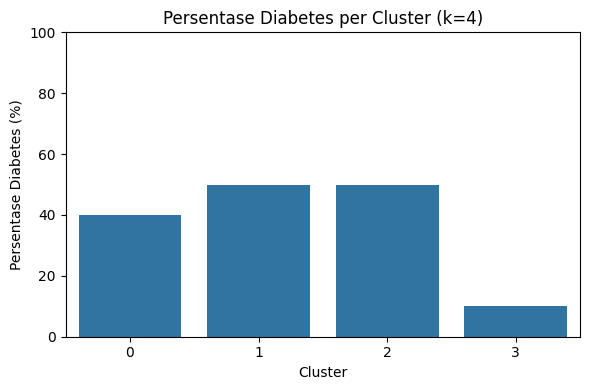

In [26]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
X = df.drop(columns="Outcome")

# 2. Scaling (pakai StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Clustering dengan KMeans (k=4)
kmeans_k4 = KMeans(n_clusters=4, random_state=42, n_init=10)
k4_labels = kmeans_k4.fit_predict(X_scaled)

# 4. Gabungkan hasil cluster ke dataframe asli
df_k4 = df.copy()
df_k4['Cluster'] = k4_labels

# 5. Hitung statistik rata-rata dan jumlah data per cluster
summary_k4 = df_k4.groupby('Cluster').mean().round(1)
summary_k4['Jumlah Data'] = df_k4['Cluster'].value_counts().sort_index()

# 6. Tampilkan ringkasan
print("=== Ringkasan Karakteristik Setiap Cluster (k=4) ===")
print(summary_k4.reset_index())

# 7. (Opsional) Visualisasi perbedaan outcome per cluster
plt.figure(figsize=(6, 4))
sns.barplot(x=summary_k4.index, y=summary_k4['Outcome'] * 100)
plt.title("Persentase Diabetes per Cluster (k=4)")
plt.xlabel("Cluster")
plt.ylabel("Persentase Diabetes (%)")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


=== Ringkasan Tiap Cluster (tanpa label Outcome) ===
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Cluster                                                                      
0                3.6    117.0            0.7            2.0      0.7  25.8   
1                2.8    142.5           73.3           35.0    204.6  37.1   
2                7.4    130.0           78.3           14.0     34.5  32.3   
3                2.2    102.4           68.2           18.2     43.2  29.4   

         DiabetesPedigreeFunction   Age  Outcome  Jumlah Data  
Cluster                                                        
0                             0.4  30.4      0.4           36  
1                             0.6  31.1      0.5          195  
2                             0.5  46.7      0.5          212  
3                             0.4  26.1      0.1          325  


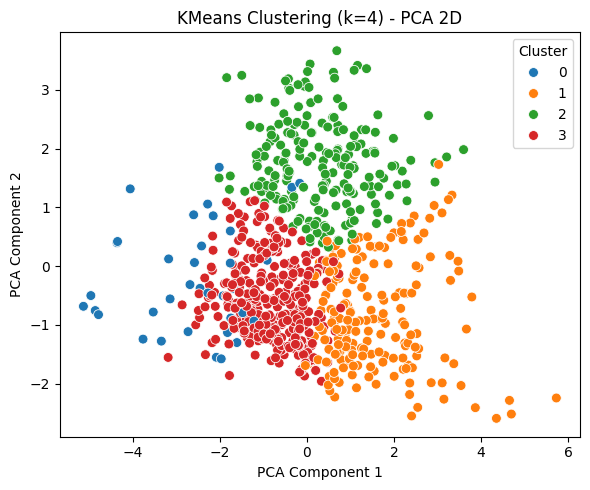

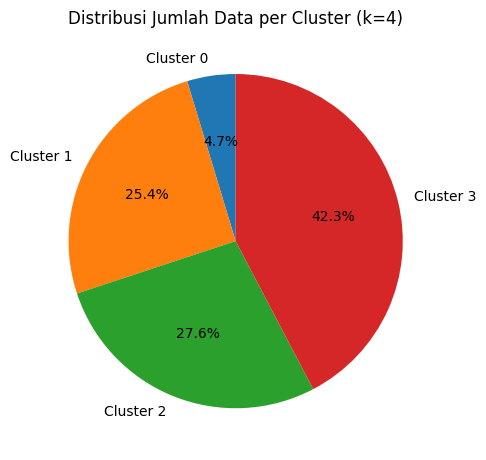

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Load data
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
X = df.drop(columns="Outcome")  # abaikan Outcome karena tidak digunakan

# 2. StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. KMeans Clustering (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. Tambahkan hasil cluster ke dataframe
df_clustered = df.copy()
df_clustered['Cluster'] = clusters

# 6. Ringkasan statistik tiap cluster
cluster_summary = df_clustered.groupby('Cluster').mean().round(1)
cluster_summary['Jumlah Data'] = df_clustered['Cluster'].value_counts().sort_index()
print("=== Ringkasan Tiap Cluster (tanpa label Outcome) ===")
print(cluster_summary)

# 7. PCA Scatter Plot
plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', s=50)
plt.title("KMeans Clustering (k=4) - PCA 2D")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# 8. Pie Chart Distribusi Cluster
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
plt.figure(figsize=(5, 5))
plt.pie(cluster_counts, labels=[f"Cluster {i}" for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("tab10"))
plt.title("Distribusi Jumlah Data per Cluster (k=4)")
plt.tight_layout()
plt.show()


In [36]:
from sklearn.metrics import adjusted_rand_score

# Load label asli
y_true = df['Outcome']  # ini label ground truth dari dataset

# ARI = seberapa mirip hasil cluster dengan label asli
ari = adjusted_rand_score(y_true, clusters)

print(f"Adjusted Rand Index (ARI) untuk k=4: {ari:.4f}")


Adjusted Rand Index (ARI) untuk k=4: 0.1367


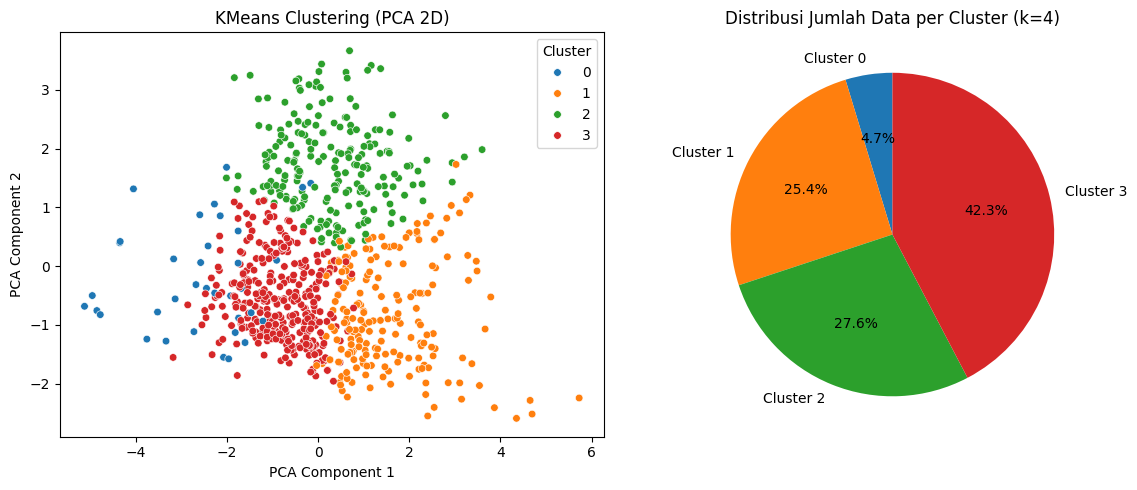

=== Ringkasan Karakteristik Tiap Cluster ===
         Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
Cluster                                                                      
0                3.6    117.0            0.7            2.0      0.7  25.8   
1                2.8    142.5           73.3           35.0    204.6  37.1   
2                7.4    130.0           78.3           14.0     34.5  32.3   
3                2.2    102.4           68.2           18.2     43.2  29.4   

         DiabetesPedigreeFunction   Age  Outcome  Jumlah Data  
Cluster                                                        
0                             0.4  30.4      0.4           36  
1                             0.6  31.1      0.5          195  
2                             0.5  46.7      0.5          212  
3                             0.4  26.1      0.1          325  

=== Evaluasi Internal & ARI ===
Adjusted Rand Index (ARI): 0.1367


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1. Load dataset
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
X = df.drop(columns="Outcome")  # Abaikan label, kita pakai unsupervised
y_true = df["Outcome"]  # Disimpan hanya untuk evaluasi ARI (opsional)

# 2. Scaling data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA untuk visualisasi 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. KMeans Clustering dengan k=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. Masukkan hasil cluster ke dataframe
df_clustered = df.copy()
df_clustered["Cluster"] = clusters

# 6. Rangkuman statistik tiap cluster
cluster_summary = df_clustered.groupby("Cluster").mean().round(1)
cluster_summary["Jumlah Data"] = df_clustered["Cluster"].value_counts().sort_index()

# 7. Visualisasi PCA Clustering & Pie Chart
plt.figure(figsize=(12, 5))

# PCA scatter plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=clusters, palette='tab10', s=30)
plt.title("KMeans Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")

# Pie chart distribusi cluster
plt.subplot(1, 2, 2)
cluster_counts = df_clustered["Cluster"].value_counts().sort_index()
plt.pie(cluster_counts, labels=[f"Cluster {i}" for i in cluster_counts.index],
        autopct='%1.1f%%', startangle=90, colors=sns.color_palette("tab10"))
plt.title("Distribusi Jumlah Data per Cluster (k=4)")
plt.tight_layout()
plt.show()

# 8. Evaluasi Internal
silhouette = silhouette_score(X_scaled, clusters)
ari = adjusted_rand_score(y_true, clusters)

# 9. Tampilkan hasil
print("=== Ringkasan Karakteristik Tiap Cluster ===")
print(cluster_summary)

print("\n=== Evaluasi Internal & ARI ===")
print(f"Adjusted Rand Index (ARI): {ari:.4f}")


C:\Users\71485\AppData\Local\Temp\ipykernel_4724\3660909067.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")


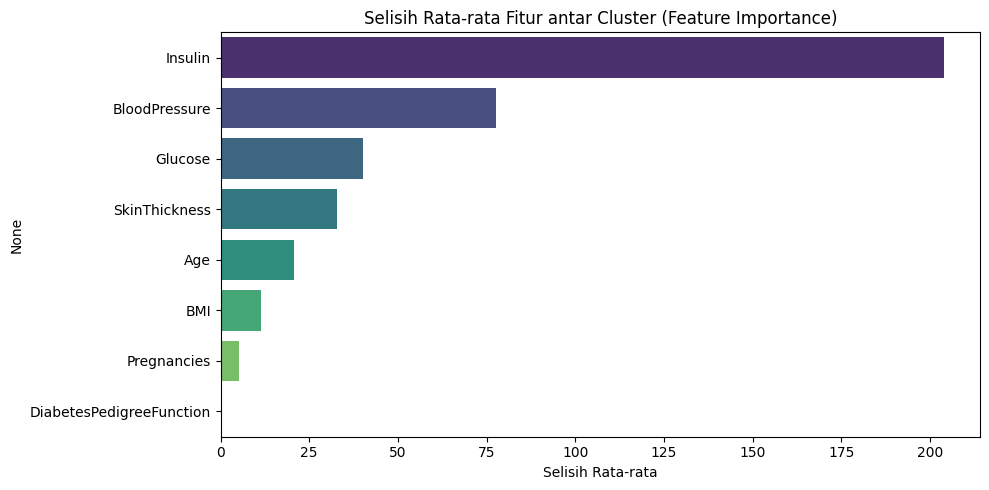

=== Selisih Rata-rata antar Cluster per Fitur ===
Insulin                     203.89
BloodPressure                77.61
Glucose                      40.12
SkinThickness                32.96
Age                          20.58
BMI                          11.34
Pregnancies                   5.27
DiabetesPedigreeFunction      0.22
dtype: float64


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Hitung selisih rata-rata tiap fitur antar cluster
# Abaikan kolom 'Outcome' (label) jika masih ada
feature_diff = df_clustered.groupby("Cluster").mean().drop(columns=["Outcome"])
feature_range = feature_diff.max() - feature_diff.min()

# 2. Urutkan berdasarkan selisih terbesar
feature_importance = feature_range.sort_values(ascending=False)

# 3. Plot bar chart feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette="viridis")
plt.xlabel("Selisih Rata-rata")
plt.title("Selisih Rata-rata Fitur antar Cluster (Feature Importance)")
plt.tight_layout()
plt.show()

# 4. (Optional) Tampilkan tabel nilai selisihnya
print("=== Selisih Rata-rata antar Cluster per Fitur ===")
print(feature_importance.round(2))


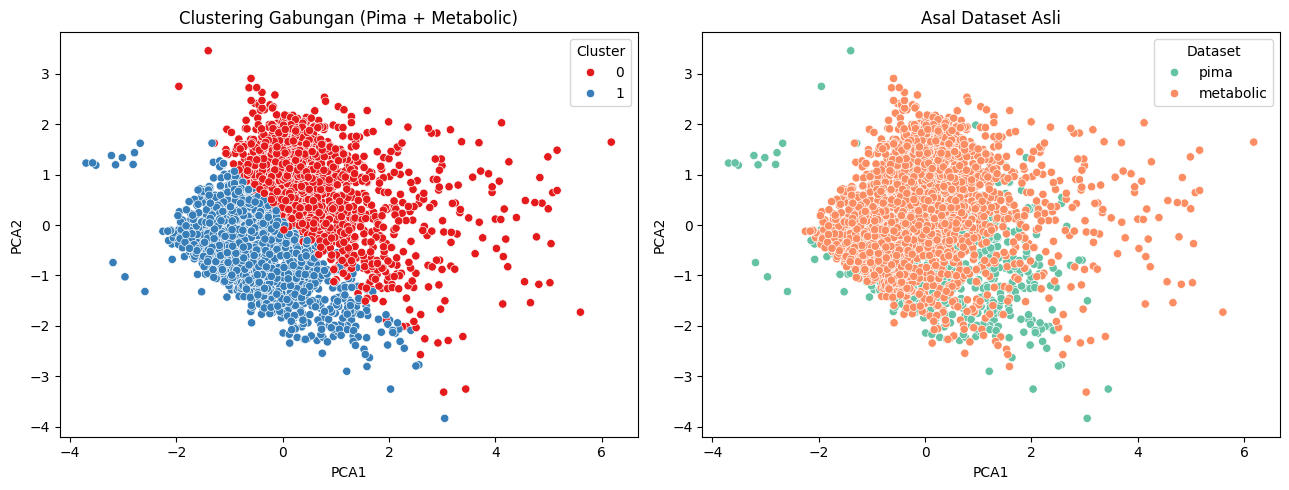

✅ Silhouette Score dari 1000 sampel gabungan: 0.3069


In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load datasets
df_pima = pd.read_csv("pima_indians_diabetes_with_header.csv")
df_metabolic = pd.read_csv("Metabolic Syndrome.csv")

# Ambil fitur yang sama (beririsan)
df_p = df_pima[['Glucose', 'BMI', 'Age']].dropna()
df_p['dataset'] = 'pima'

df_m = df_metabolic[['BloodGlucose', 'BMI', 'Age']].dropna()
df_m.columns = ['Glucose', 'BMI', 'Age']
df_m['dataset'] = 'metabolic'

# Gabungkan
df_all = pd.concat([df_p, df_m], ignore_index=True)

# Standarisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_all[['Glucose', 'BMI', 'Age']])

# Clustering k=2
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df_all['Cluster'] = clusters

# PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_all[['PCA1', 'PCA2']] = X_pca

# Silhouette Score dari SAMPEL (agar hemat memori)
sample_df = df_all.sample(n=1000, random_state=42)
sample_X = scaler.transform(sample_df[['Glucose', 'BMI', 'Age']])
sample_clusters = sample_df['Cluster']
sil_score = silhouette_score(sample_X, sample_clusters)

# Plot
fig, axs = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='Cluster', palette='Set1', ax=axs[0])
axs[0].set_title("Clustering Gabungan (Pima + Metabolic)")
axs[0].legend(title="Cluster")

sns.scatterplot(data=df_all, x='PCA1', y='PCA2', hue='dataset', palette='Set2', ax=axs[1])
axs[1].set_title("Asal Dataset Asli")
axs[1].legend(title="Dataset")

plt.tight_layout()
plt.show()

print(f"✅ Silhouette Score dari 1000 sampel gabungan: {sil_score:.4f}")


In [90]:
import pandas as pd

# Tabel manual korelasi fitur dengan risiko kesehatan
korelasi_data = pd.DataFrame({
    "Fitur": [
        "Pregnancies", 
        "Glucose", 
        "BloodPressure", 
        "SkinThickness", 
        "Insulin", 
        "BMI", 
        "DiabetesPedigreeFunction", 
        "Age"
    ],
    "Berkaitan dengan": [
        "Diabetes gestasional, riwayat kehamilan", 
        "Diabetes, prediabetes, sindrom metabolik", 
        "Hipertensi, penyakit jantung", 
        "Obesitas, sindrom metabolik", 
        "Resistensi insulin, prediabetes", 
        "Obesitas, risiko jantung, sindrom metabolik", 
        "Faktor genetik untuk diabetes", 
        "Risiko diabetes, GDM, penyakit kronis"
    ],
    "Penyakit Terkait / Risiko Kesehatan": [
        "GDM (Gestational Diabetes Mellitus)", 
        "Diabetes, Prediabetes", 
        "Hipertensi, stroke", 
        "Obesitas abdominal", 
        "Resistensi insulin", 
        "Obesitas, penyakit kardiovaskular", 
        "Faktor genetik terhadap diabetes", 
        "Diabetes, sindrom metabolik, GDM"
    ]
})

# Tampilkan tabel
print("=== Korelasi Fitur Dataset dengan Risiko Kesehatan ===")
print(korelasi_data.to_string(index=False))

=== Korelasi Fitur Dataset dengan Risiko Kesehatan ===
                   Fitur                            Berkaitan dengan Penyakit Terkait / Risiko Kesehatan
             Pregnancies     Diabetes gestasional, riwayat kehamilan GDM (Gestational Diabetes Mellitus)
                 Glucose    Diabetes, prediabetes, sindrom metabolik               Diabetes, Prediabetes
           BloodPressure                Hipertensi, penyakit jantung                  Hipertensi, stroke
           SkinThickness                 Obesitas, sindrom metabolik                  Obesitas abdominal
                 Insulin             Resistensi insulin, prediabetes                  Resistensi insulin
                     BMI Obesitas, risiko jantung, sindrom metabolik   Obesitas, penyakit kardiovaskular
DiabetesPedigreeFunction               Faktor genetik untuk diabetes    Faktor genetik terhadap diabetes
                     Age       Risiko diabetes, GDM, penyakit kronis    Diabetes, sindrom metabolik, GDM


=== Ringkasan Karakteristik Tiap Label ===
                                    Pregnancies  Glucose  BloodPressure  \
Cluster_Label                                                             
Norma Glukosa & BMI                         2.2    102.4           68.2   
Relatif Muda, Tekanan Darah Rendah          3.6    117.0            0.7   
Tinggi Insulin & Glukosa                    2.8    142.5           73.3   
Usia Tua, BMI Tinggi                        7.4    130.0           78.3   

                                    SkinThickness  Insulin   BMI  \
Cluster_Label                                                      
Norma Glukosa & BMI                          18.2     43.2  29.4   
Relatif Muda, Tekanan Darah Rendah            2.0      0.7  25.8   
Tinggi Insulin & Glukosa                     35.0    204.6  37.1   
Usia Tua, BMI Tinggi                         14.0     34.5  32.3   

                                    DiabetesPedigreeFunction   Age  Outcome  \
Cluster_Label     

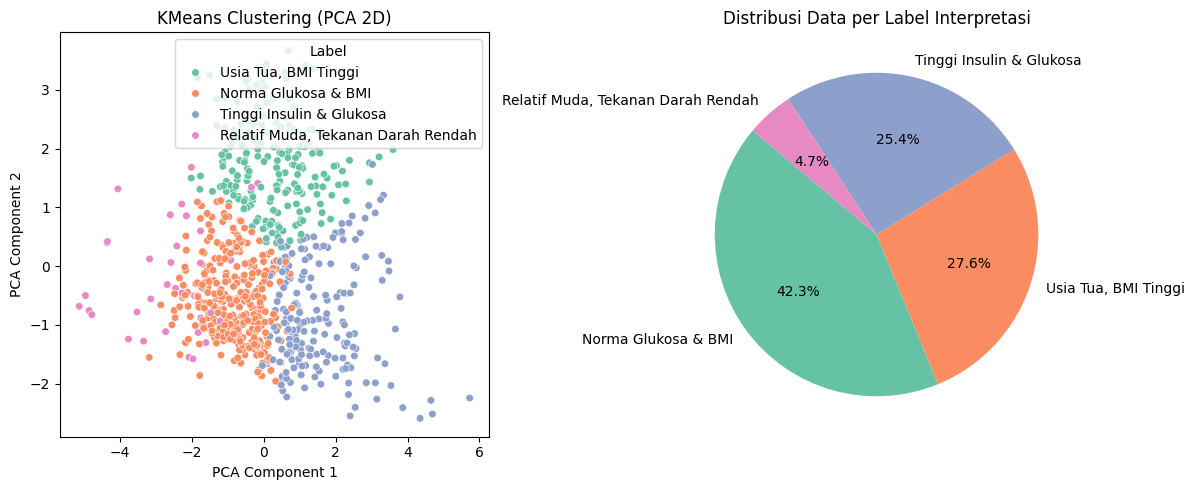


=== Evaluasi Clustering ===
Silhouette Score: 0.1949
Adjusted Rand Index (ARI) vs Outcome: 0.1367


In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# 1. Load dataset
df = pd.read_csv("pima_indians_diabetes_with_header.csv")
y_true = df["Outcome"]
X = df.drop(columns=["Outcome"])  # gunakan semua fitur kecuali label

# 2. Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. PCA untuk visualisasi
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4. Clustering KMeans (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# 5. Gabungkan hasil ke dataframe
df_clustered = df.copy()
df_clustered["Cluster"] = clusters

# 6. Analisis fitur dominan di tiap cluster untuk interpretasi
cluster_means = df_clustered.groupby("Cluster").mean().round(1)
feature_diffs = (cluster_means - cluster_means.mean()).abs()
dominant_features = feature_diffs.apply(lambda row: row.sort_values(ascending=False).index.tolist(), axis=1)

# Buat label manual berdasarkan eksplorasi fitur dominan
manual_labels = {
    0: "Relatif Muda, Tekanan Darah Rendah",
    1: "Tinggi Insulin & Glukosa",
    2: "Usia Tua, BMI Tinggi",
    3: "Norma Glukosa & BMI"
}
df_clustered["Cluster_Label"] = df_clustered["Cluster"].map(manual_labels)

# 7. Ringkasan per label
cluster_summary = df_clustered.groupby("Cluster_Label").mean().round(1)
cluster_summary["Jumlah Data"] = df_clustered["Cluster_Label"].value_counts()
print("=== Ringkasan Karakteristik Tiap Label ===")
print(cluster_summary)

# 8. Visualisasi
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# PCA Scatter plot
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clustered["Cluster_Label"],
                palette="Set2", s=30, ax=axs[0])
axs[0].set_title("KMeans Clustering (PCA 2D)")
axs[0].set_xlabel("PCA Component 1")
axs[0].set_ylabel("PCA Component 2")
axs[0].legend(title="Label")

# Pie chart distribusi
label_counts = df_clustered["Cluster_Label"].value_counts()
axs[1].pie(label_counts, labels=label_counts.index, autopct='%1.1f%%',
           startangle=140, colors=sns.color_palette("Set2"))
axs[1].set_title("Distribusi Data per Label Interpretasi")

plt.tight_layout()
plt.show()

# 9. Evaluasi Internal
silhouette = silhouette_score(X_scaled, clusters)
ari = adjusted_rand_score(y_true, clusters)

print("\n=== Evaluasi Clustering ===")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Adjusted Rand Index (ARI) vs Outcome: {ari:.4f}")
